In [1]:
# Importamos las bibliotecas necesarias
# reticulate::py_install("scikit-learn-extra", pip = TRUE)
# pip install scikit-learn-extra
import os
import numpy as np
import pandas as pd
import seaborn as sb
from   math import pi
import plotly.express as px
import No_Supervisados as ns
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.datasets import make_blobs
from sklearn.decomposition import PCA
from scipy.spatial.distance import pdist
from sklearn_extra.cluster import KMedoids
from sklearn.preprocessing import StandardScaler
pd.options.display.max_rows = 10
import warnings

In [2]:
import No_Supervisados

In [3]:
# Opción a
path = "/home/dnunezf/Documents/AI_LABS/Lab_12-03-2026/movies_budget.csv"
df = pd.read_csv(path,delimiter=',',decimal=".", index_col=0)

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 15 entries, 1 to 15
Data columns (total 7 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   budget_musd      15 non-null     int64  
 1   box_office_musd  15 non-null     int64  
 2   runtime_min      15 non-null     int64  
 3   imdb_rating      15 non-null     float64
 4   metascore        15 non-null     int64  
 5   votes_thousands  15 non-null     int64  
 6   year             15 non-null     int64  
dtypes: float64(1), int64(6)
memory usage: 960.0 bytes


In [5]:
df.shape

(15, 7)

In [6]:
df.dtypes

budget_musd          int64
box_office_musd      int64
runtime_min          int64
imdb_rating        float64
metascore            int64
votes_thousands      int64
year                 int64
dtype: object

In [7]:
df.head()

,budget_musd,box_office_musd,runtime_min,imdb_rating,metascore,votes_thousands,year
movie_id,,,,,,,
1,160,829,136,8.5,84,1800,2014
2,200,1347,152,7.8,75,2100,2015
3,150,873,141,8.1,79,1650,2016
4,90,463,113,7.3,68,980,2012
5,120,657,130,7.6,72,1200,2013


In [8]:
df_numerico = df.select_dtypes(include = ["number"])

In [9]:
df_numerico.info()

<class 'pandas.core.frame.DataFrame'>
Index: 15 entries, 1 to 15
Data columns (total 7 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   budget_musd      15 non-null     int64  
 1   box_office_musd  15 non-null     int64  
 2   runtime_min      15 non-null     int64  
 3   imdb_rating      15 non-null     float64
 4   metascore        15 non-null     int64  
 5   votes_thousands  15 non-null     int64  
 6   year             15 non-null     int64  
dtypes: float64(1), int64(6)
memory usage: 960.0 bytes


In [10]:
#Opción b
import warnings
warnings.filterwarnings('ignore')
# Ejecuta k-medias con 3 clusters
kmedias = KMeans(n_clusters=3, max_iter=500, n_init=150)  # Declara la instancia de clase
kmedias.fit(df_numerico)
print("Grupos\n",kmedias.predict(df_numerico))
centros = np.array(kmedias.cluster_centers_)
print("Centros\n",centros)

Grupos
 [1 2 1 0 1 2 0 2 1 0 1 1 0 2 0]
Centros
 [[  86.          401.6         112.2           7.04         65.4
   790.         2012.4       ]
 [ 145.          831.5         137.33333333    7.96666667   77.5
  1533.33333333 2015.66666667]
 [ 202.5        1348.          155.75          8.325        82.5
  2212.5        2017.75      ]]


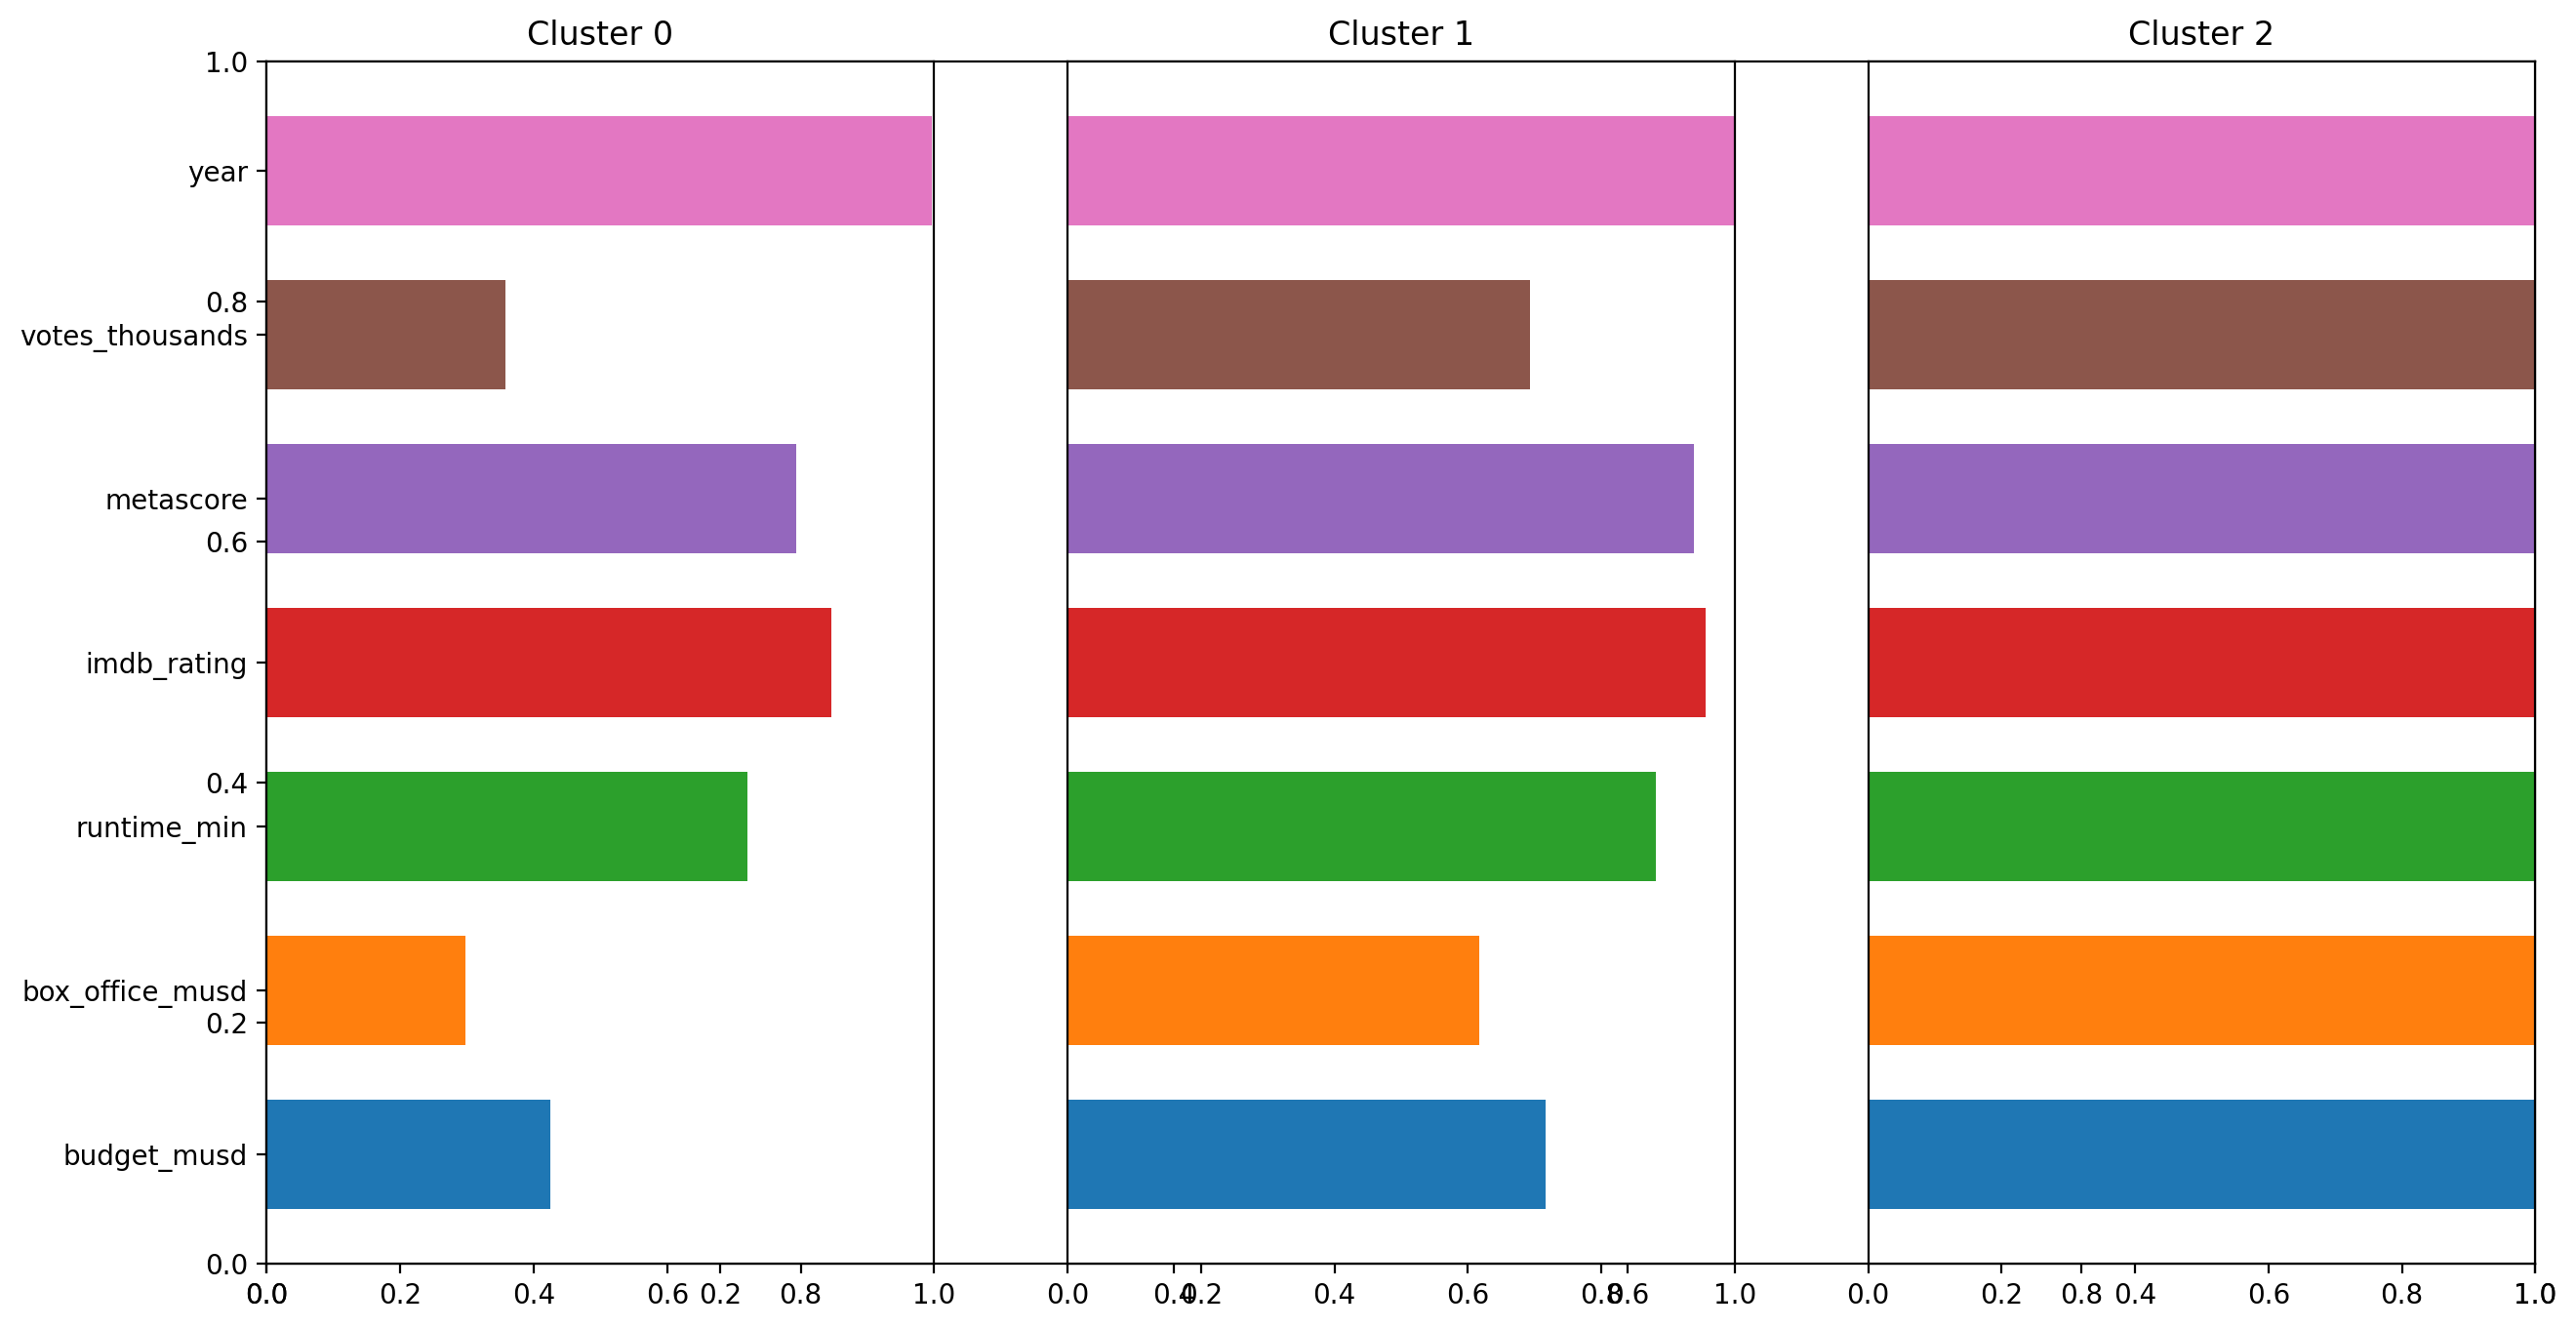

In [11]:
ns.bar_plot(centros, df_numerico.columns,scale=True)
plt.show()

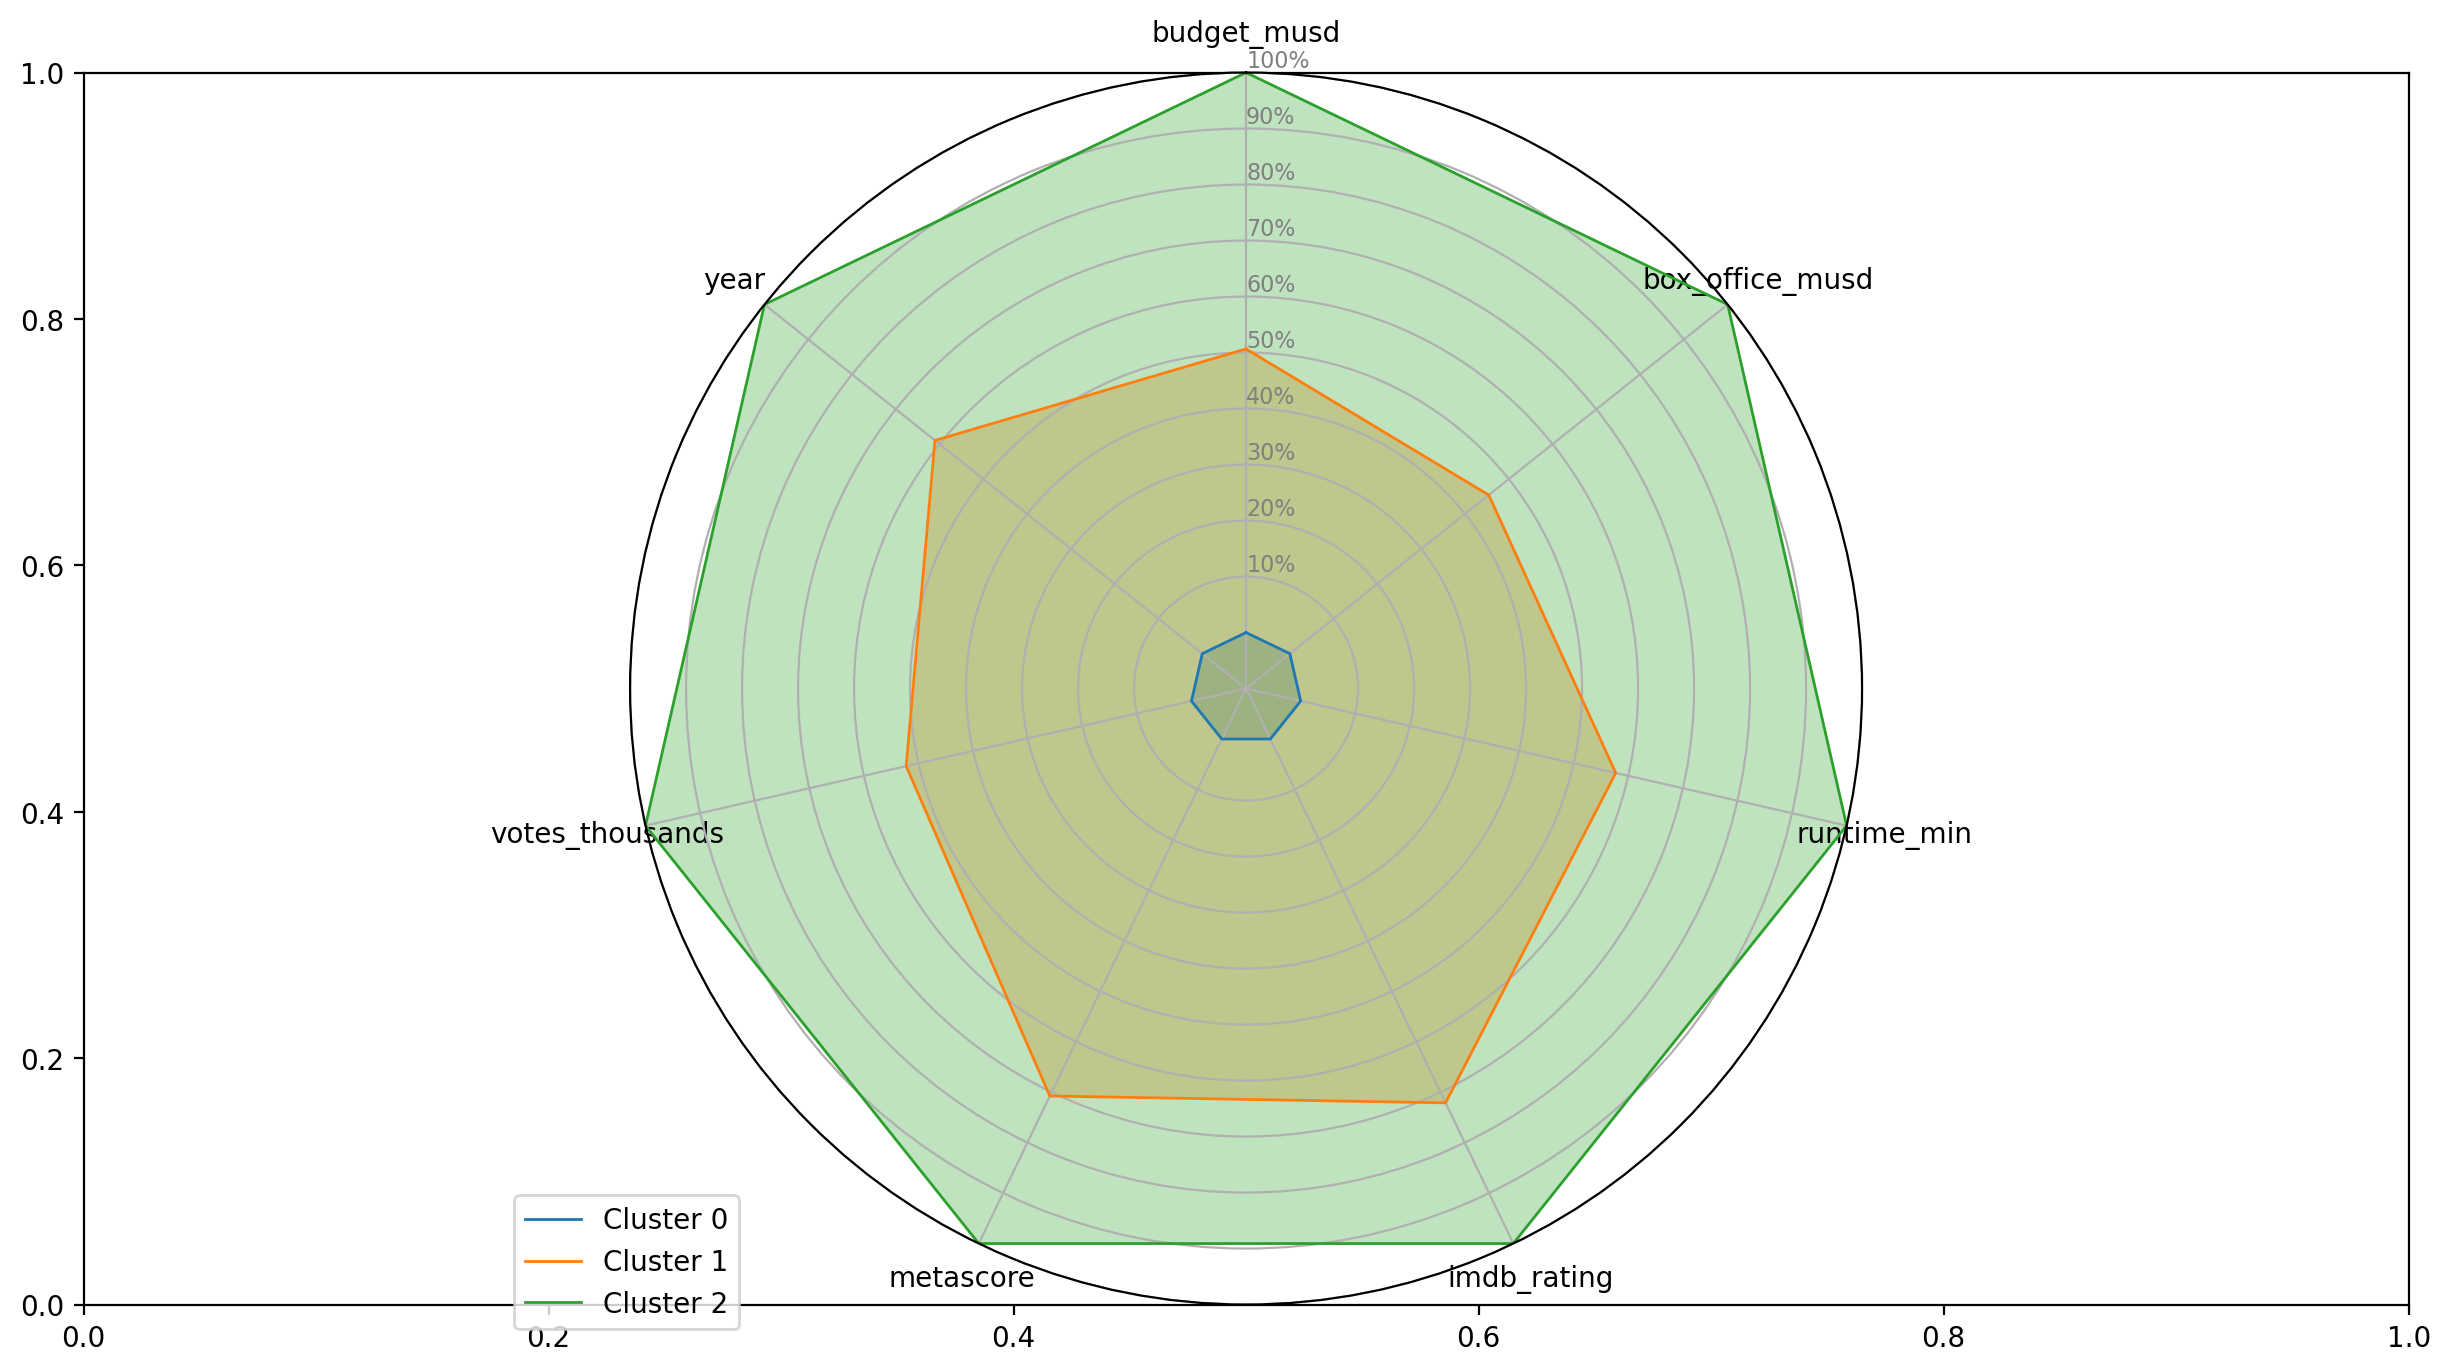

In [12]:
ns.radar_plot(centros, df_numerico.columns)
plt.show()

Datos shape
 (15, 7)
Componentes shape
 (15, 2)
Componentes
 [[  282.37814991  -178.39879758]
 [  817.01088009    94.38301866]
 [  179.92263718   -59.97540214]
 [ -608.13966259   -40.97898468]
 [ -316.34852189     2.77935618]
 [  567.13594552   -15.17615257]
 [ -963.24847526    18.01586209]
 [ 1239.45386043     9.75550444]
 [   73.49619114    52.42622115]
 [-1214.00274497    54.67213063]
 [ -144.96137484    -8.88508187]
 [  281.17497674     2.92133352]
 [ -787.11617926    12.45417252]
 [ 1025.03165789    46.86780085]
 [ -431.78734009     9.13901881]]


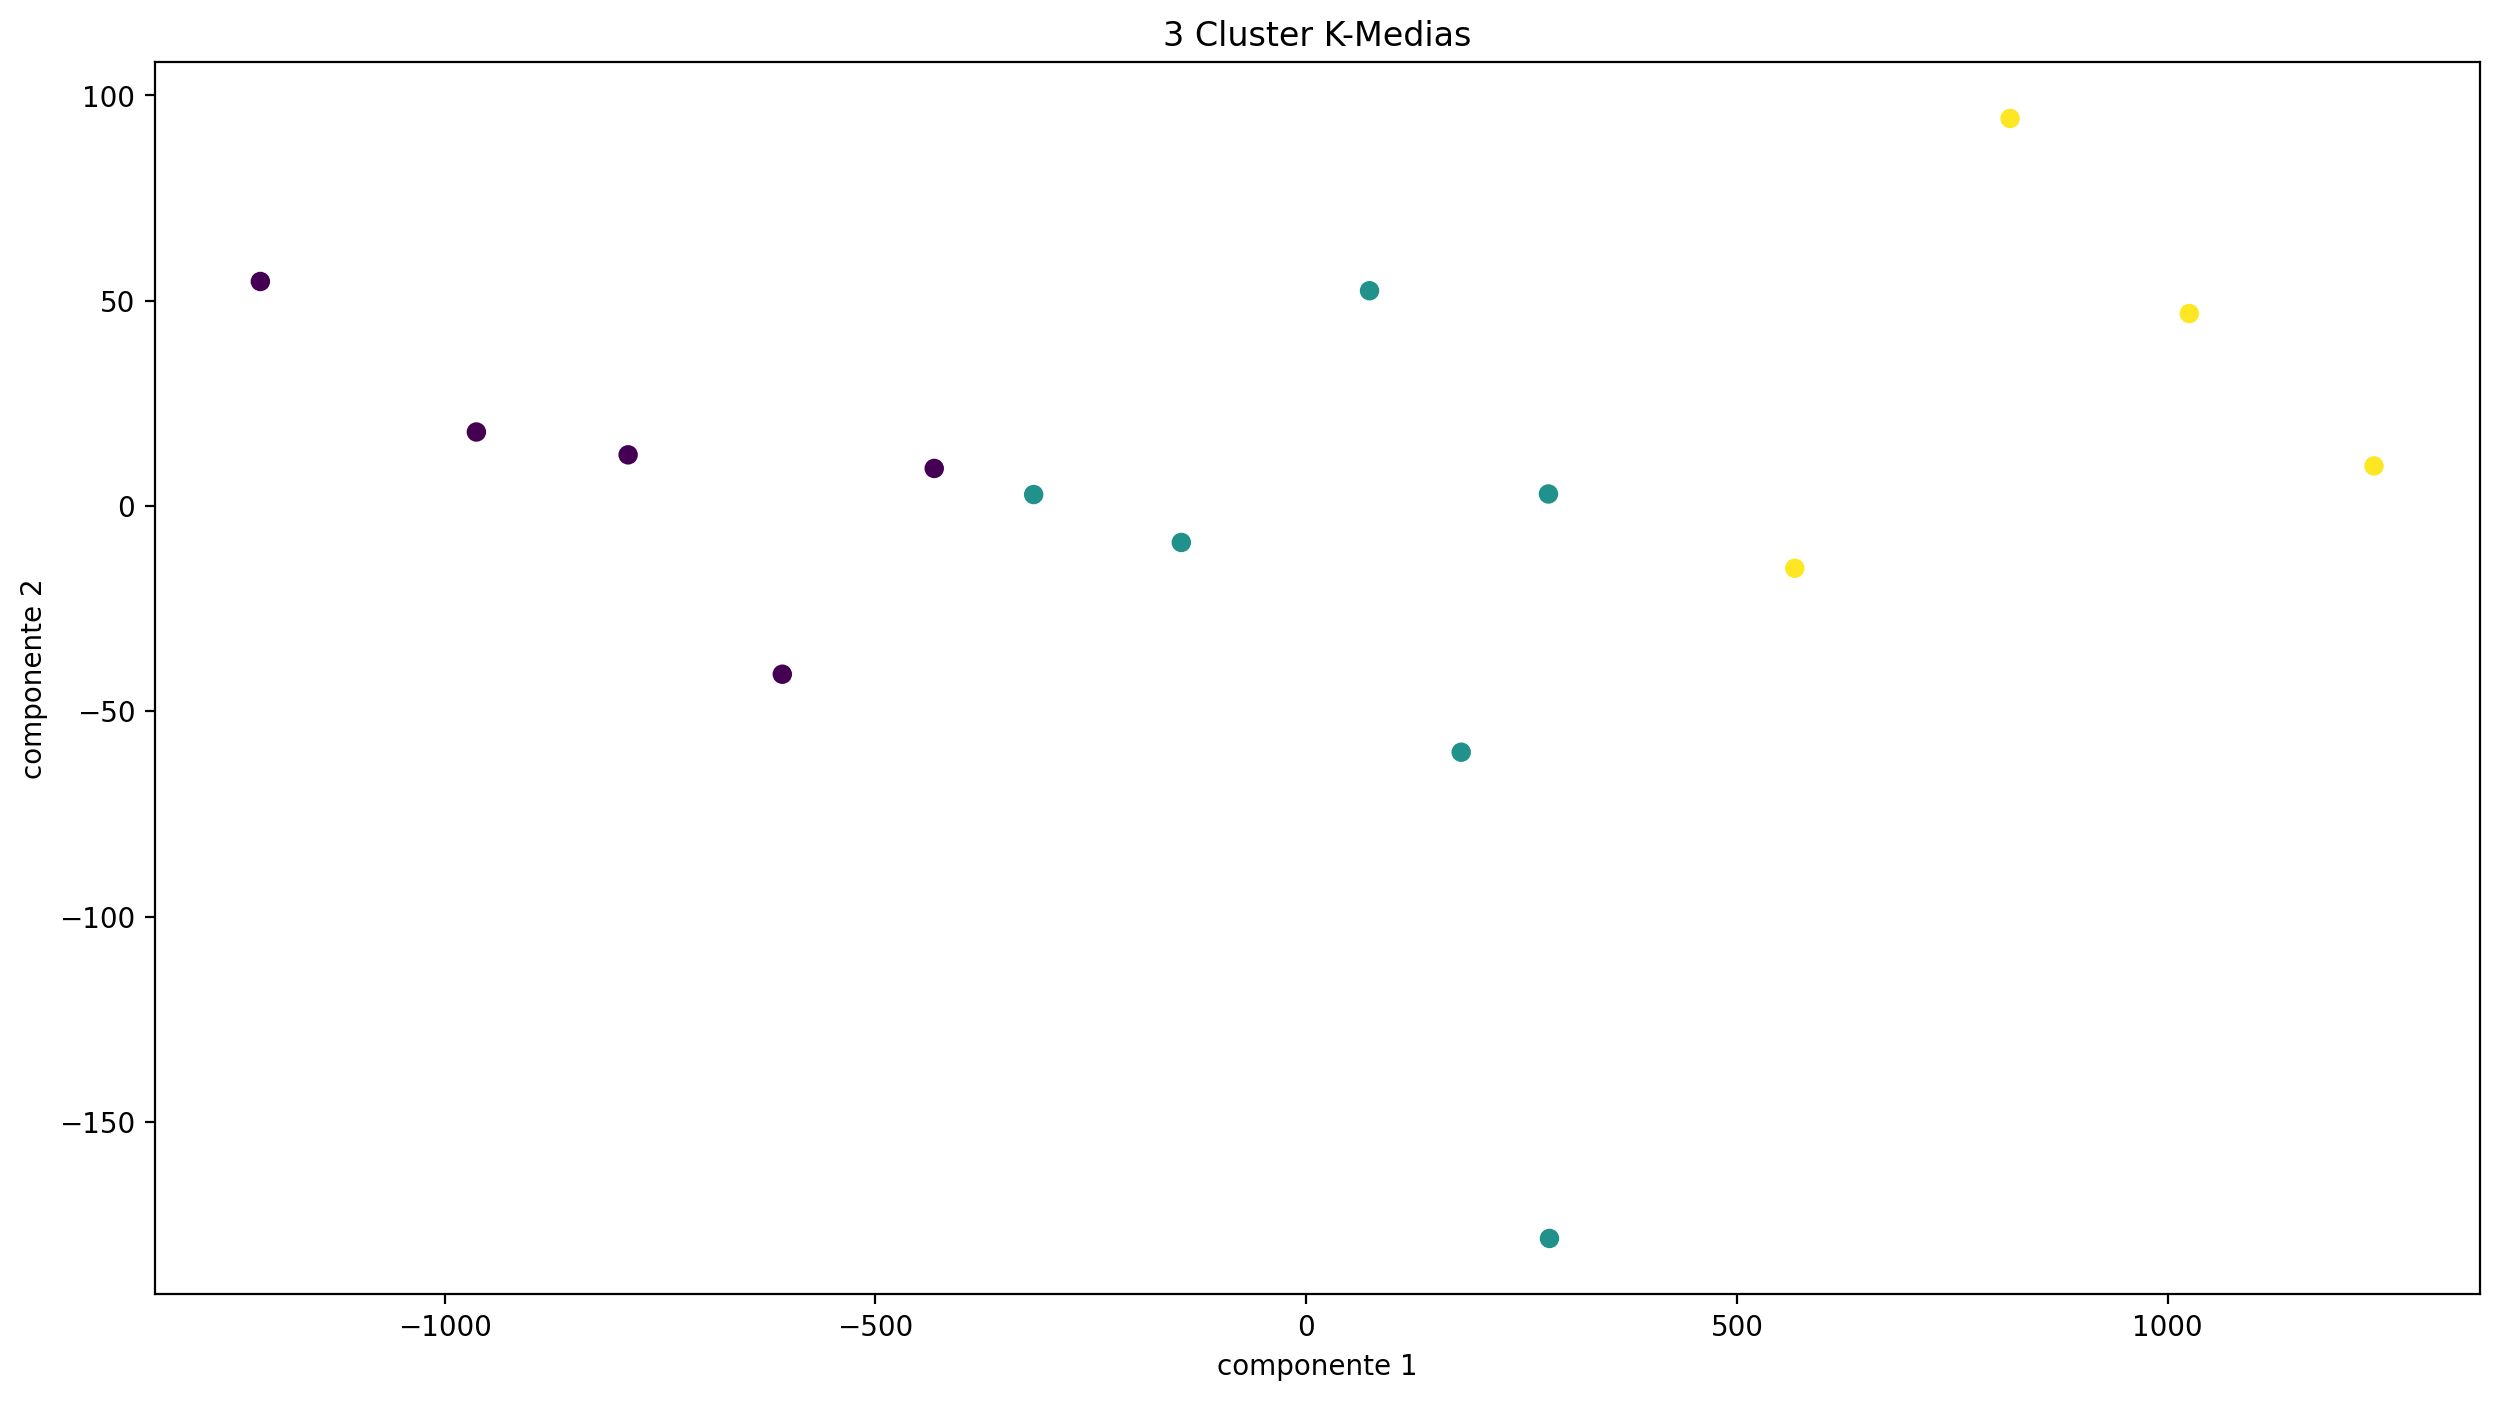

In [13]:
pca = PCA(n_components=2)
componentes = pca.fit_transform(df_numerico)
print("Datos shape\n",df_numerico.shape)
print("Componentes shape\n",componentes.shape)
print("Componentes\n",componentes)

fig, ax = plt.subplots(1,1, figsize = (15,8), dpi = 200)
ax.scatter(componentes[:, 0], componentes[:, 1],c=kmedias.predict(df_numerico))
ax.set_xlabel('componente 1')
ax.set_ylabel('componente 2')
ax.set_title('3 Cluster K-Medias')
plt.show()

In [14]:
#opción c
# Ejecuta k-medoids con 3 clusters
kmedoids = KMedoids(n_clusters=3, max_iter=500, metric='cityblock')  # Declara la instancia de clase
kmedoids.fit(df_numerico)
print("Grupos\n",kmedoids.labels_)
centros = np.array(kmedoids.cluster_centers_)
print("Centros\n",centros)

Grupos
 [0 1 0 2 2 0 2 1 0 2 0 0 2 1 2]
Centros
 [[ 150.   873.   141.     8.1   79.  1650.  2016. ]
 [ 210.  1420.   158.     8.6   86.  2300.  2020. ]
 [  90.   463.   113.     7.3   68.   980.  2012. ]]


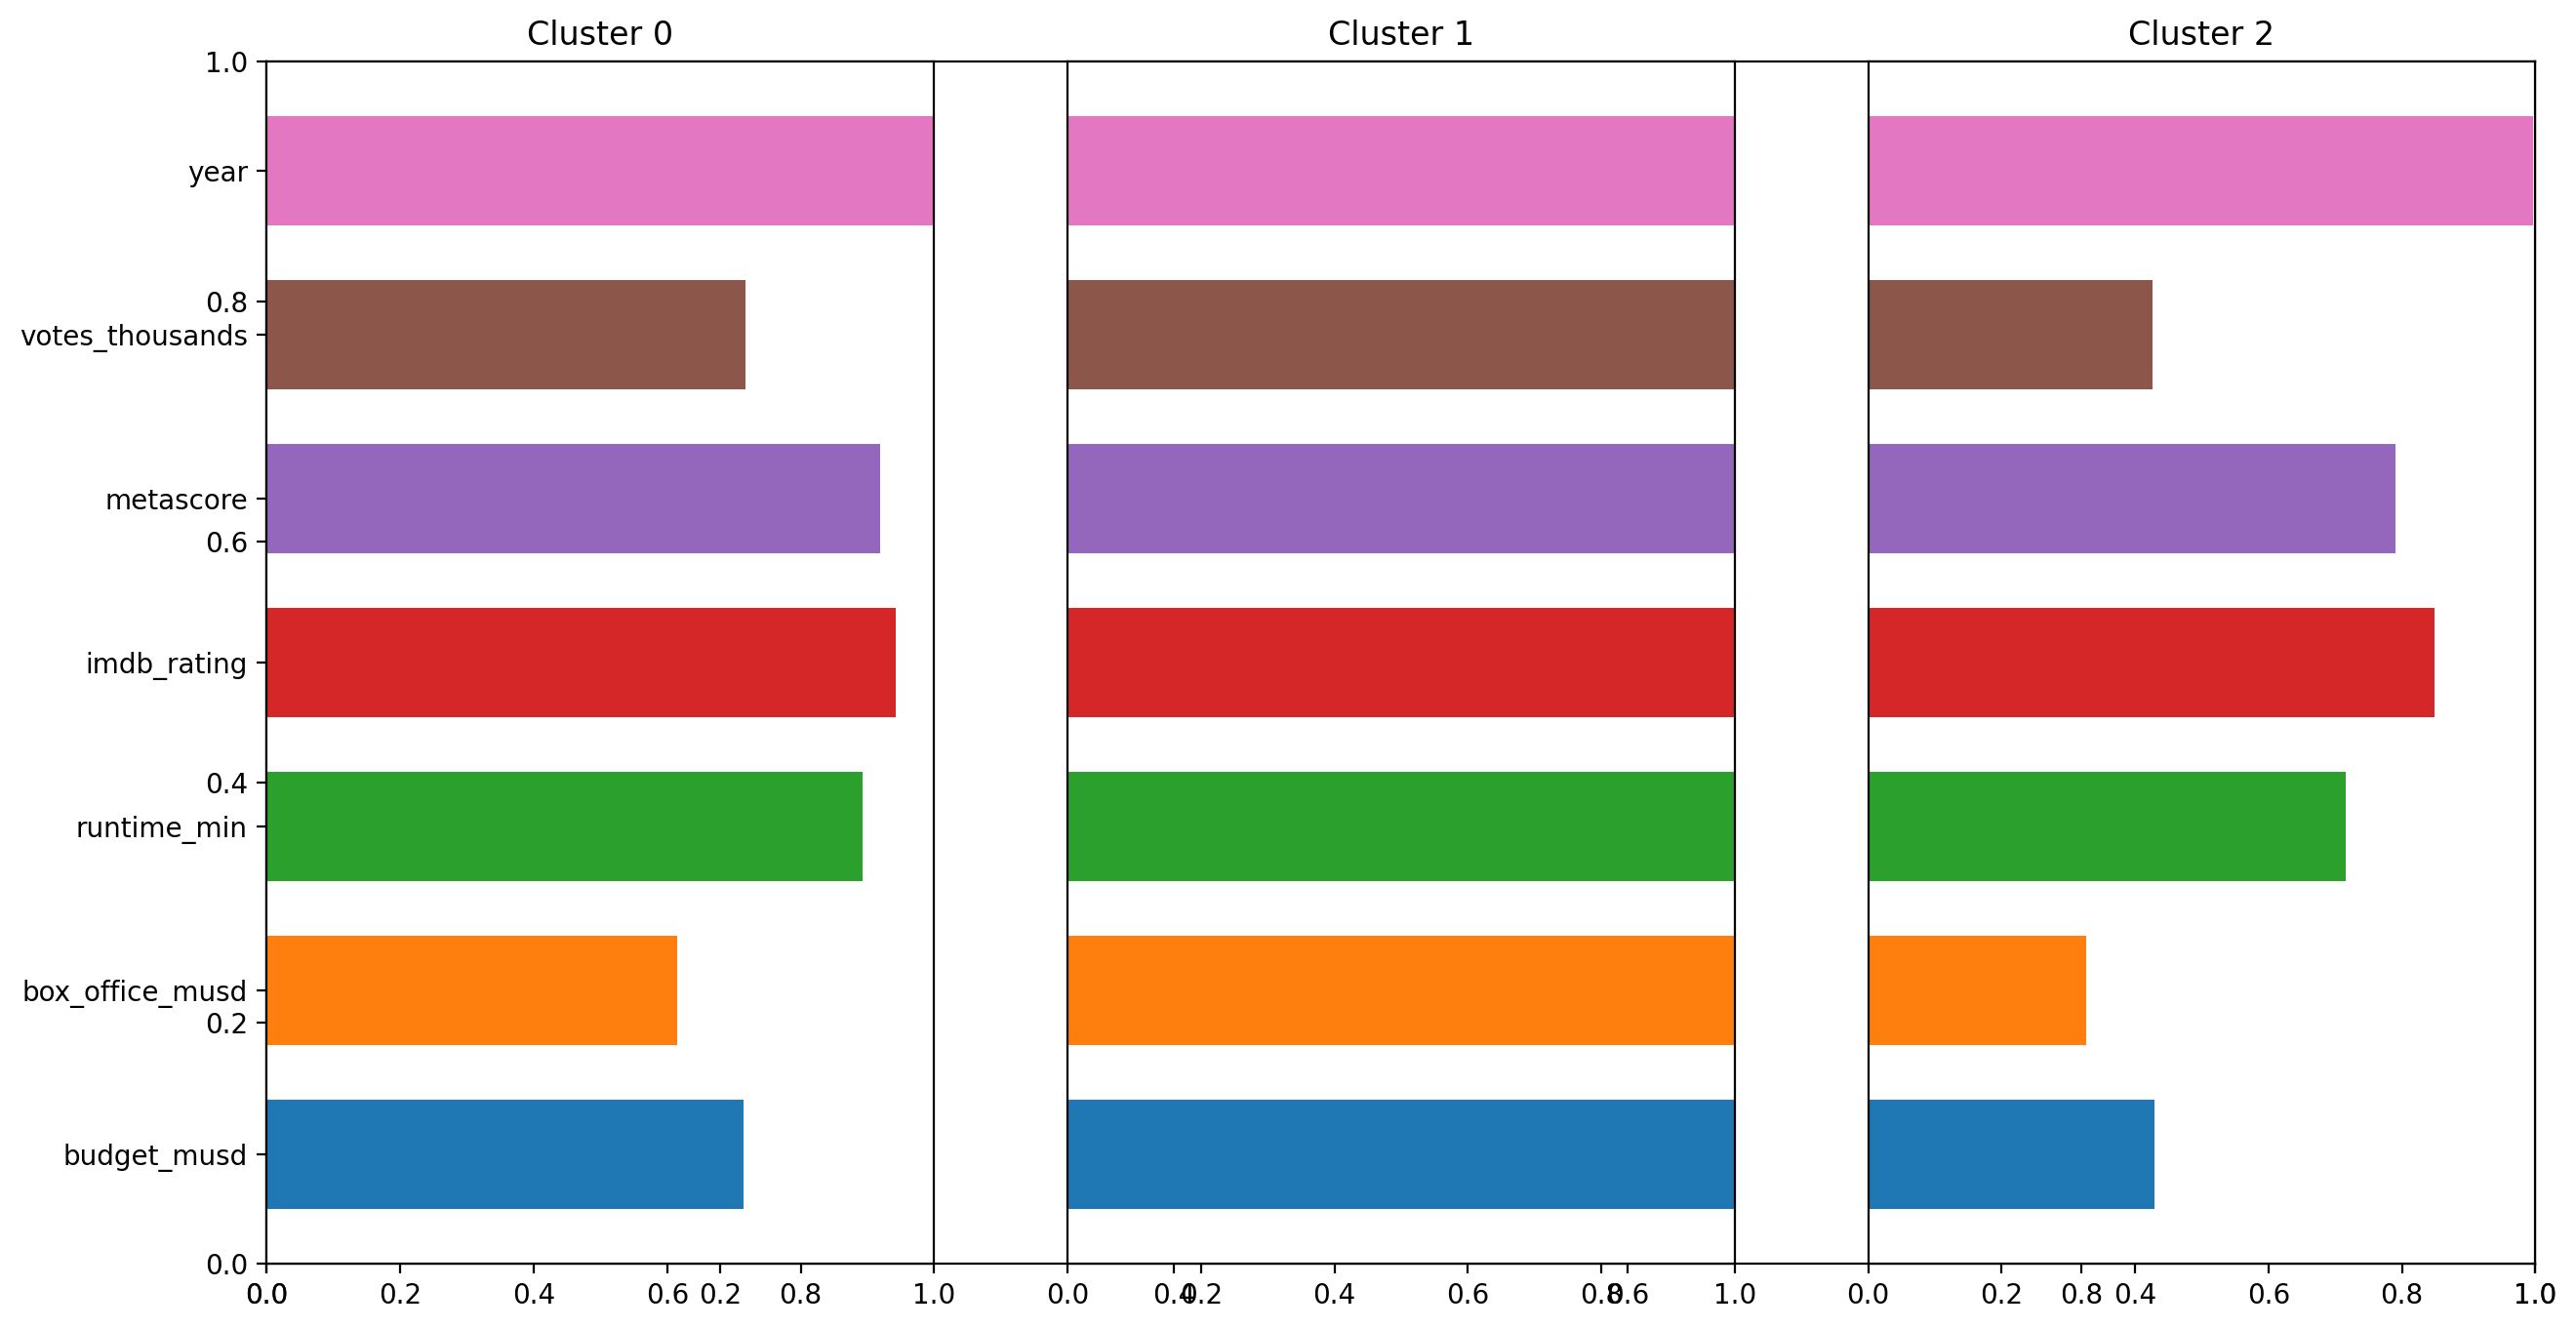

In [15]:
ns.bar_plot(centros, df_numerico.columns,scale=True)
plt.show()

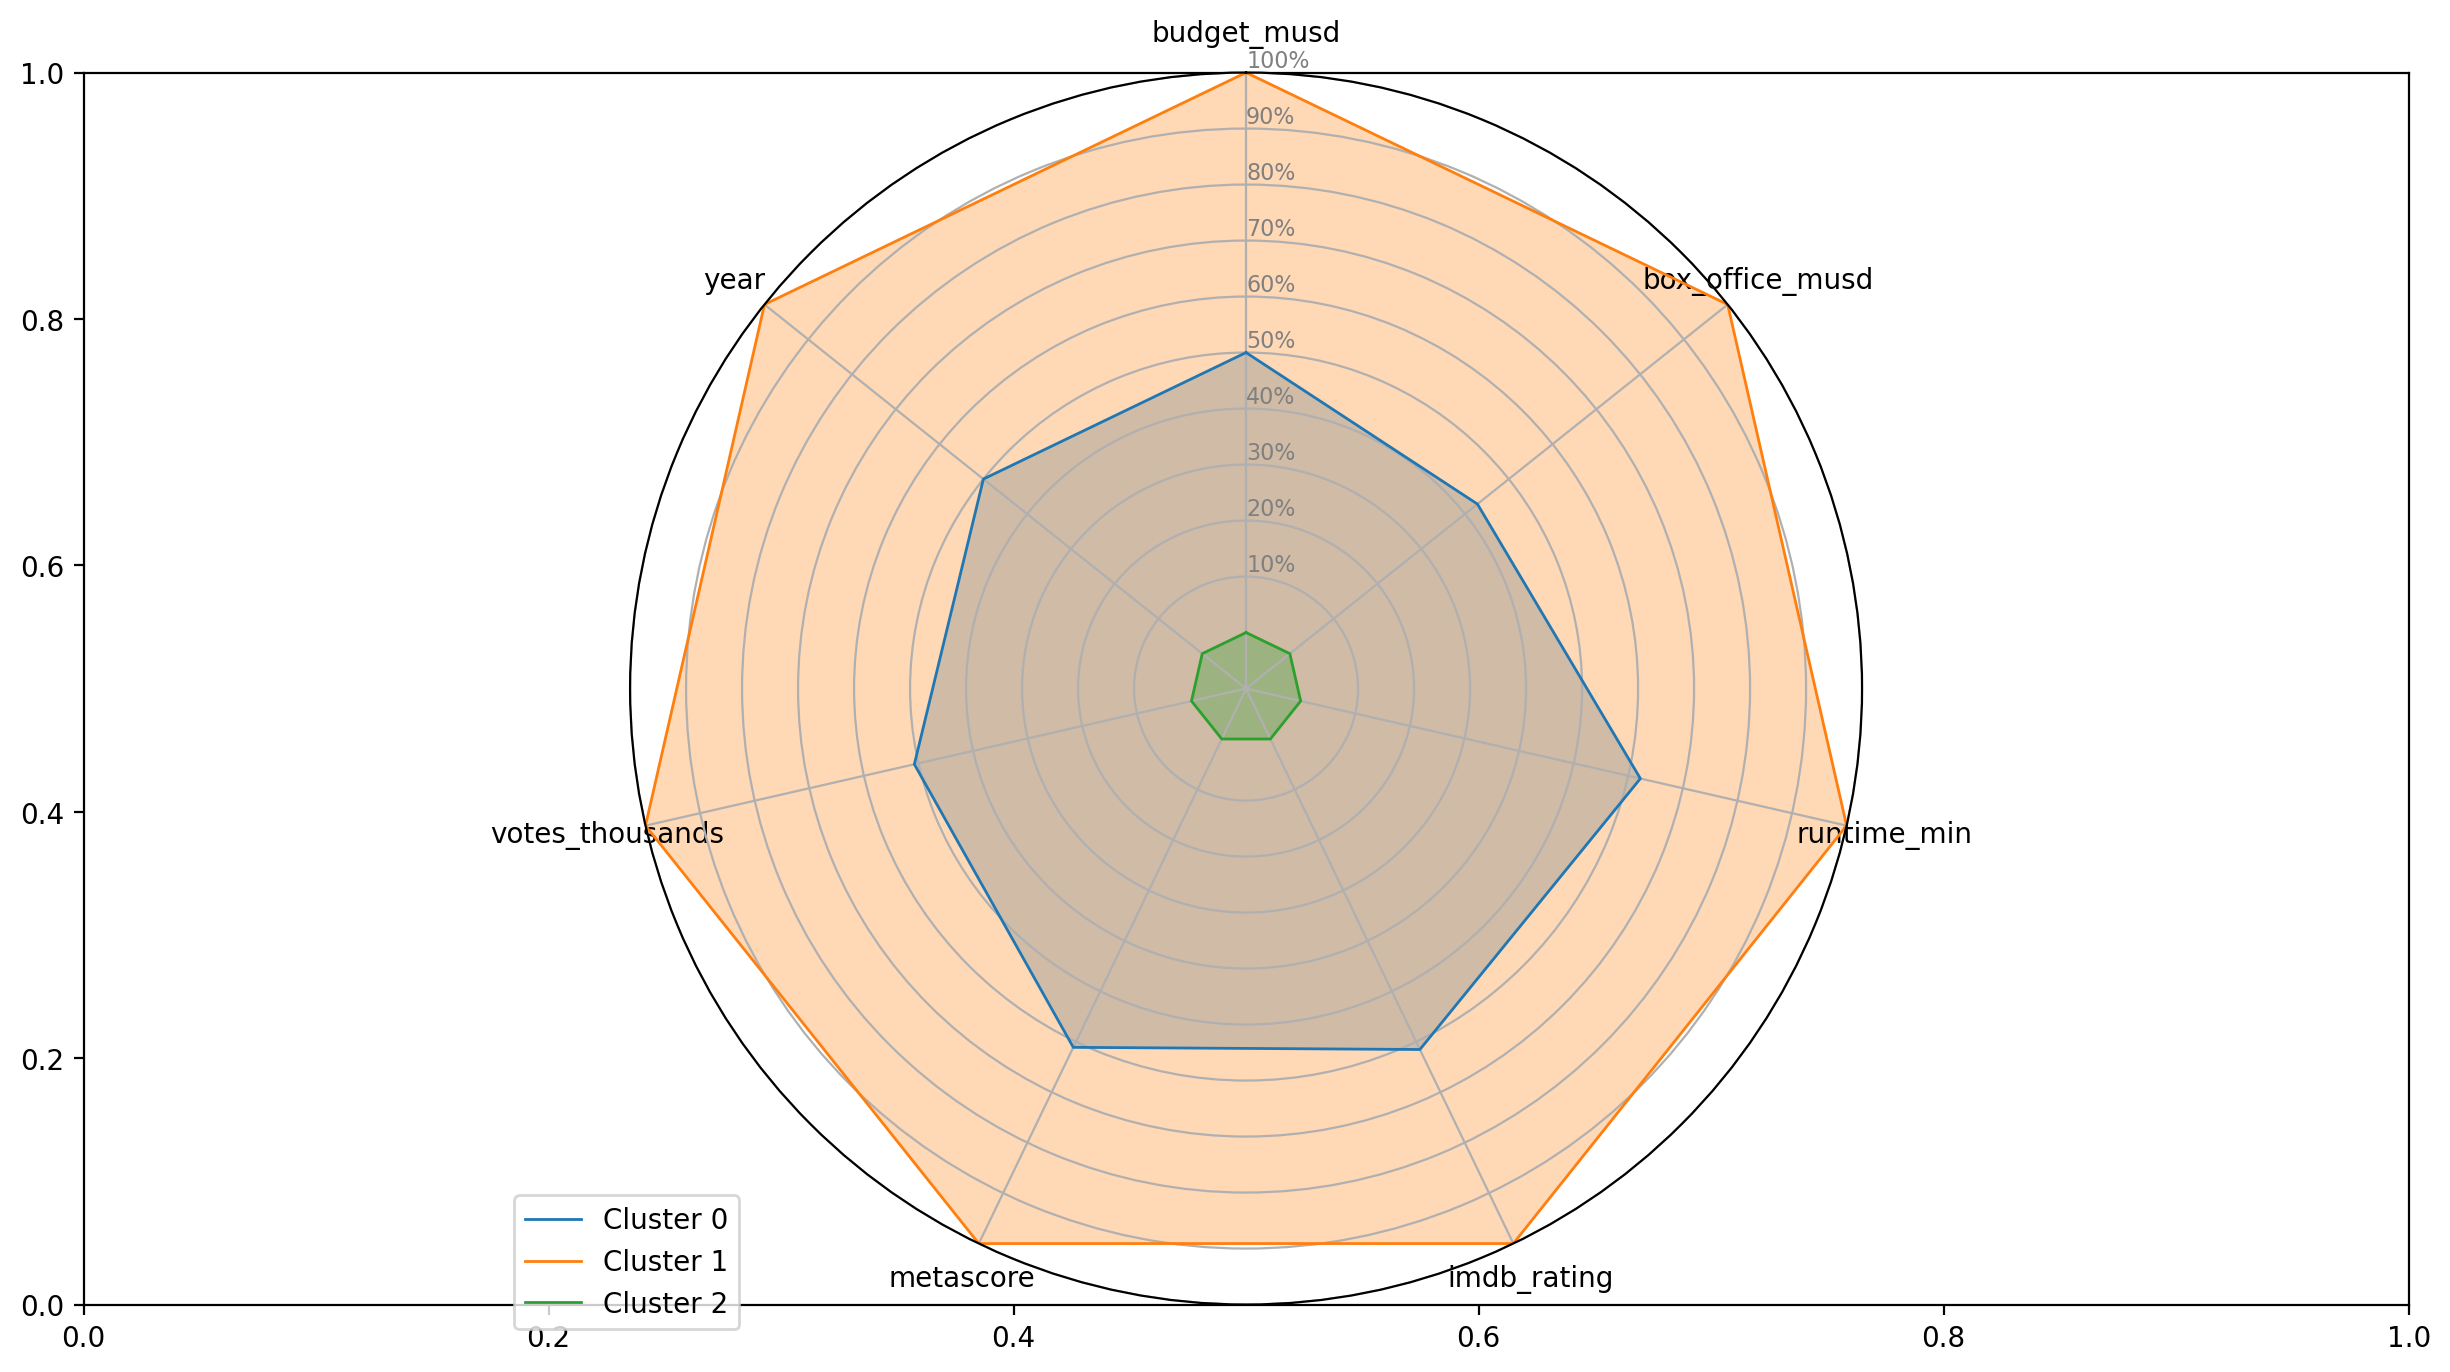

In [16]:
ns.radar_plot(centros, df_numerico.columns)
plt.show()

Datos shape
 (15, 7)
Componentes shape
 (15, 2)
Componentes
 [[  282.37814991  -178.39879758]
 [  817.01088009    94.38301866]
 [  179.92263718   -59.97540214]
 [ -608.13966259   -40.97898468]
 [ -316.34852189     2.77935618]
 [  567.13594552   -15.17615257]
 [ -963.24847526    18.01586209]
 [ 1239.45386043     9.75550444]
 [   73.49619114    52.42622115]
 [-1214.00274497    54.67213063]
 [ -144.96137484    -8.88508187]
 [  281.17497674     2.92133352]
 [ -787.11617926    12.45417252]
 [ 1025.03165789    46.86780085]
 [ -431.78734009     9.13901881]]


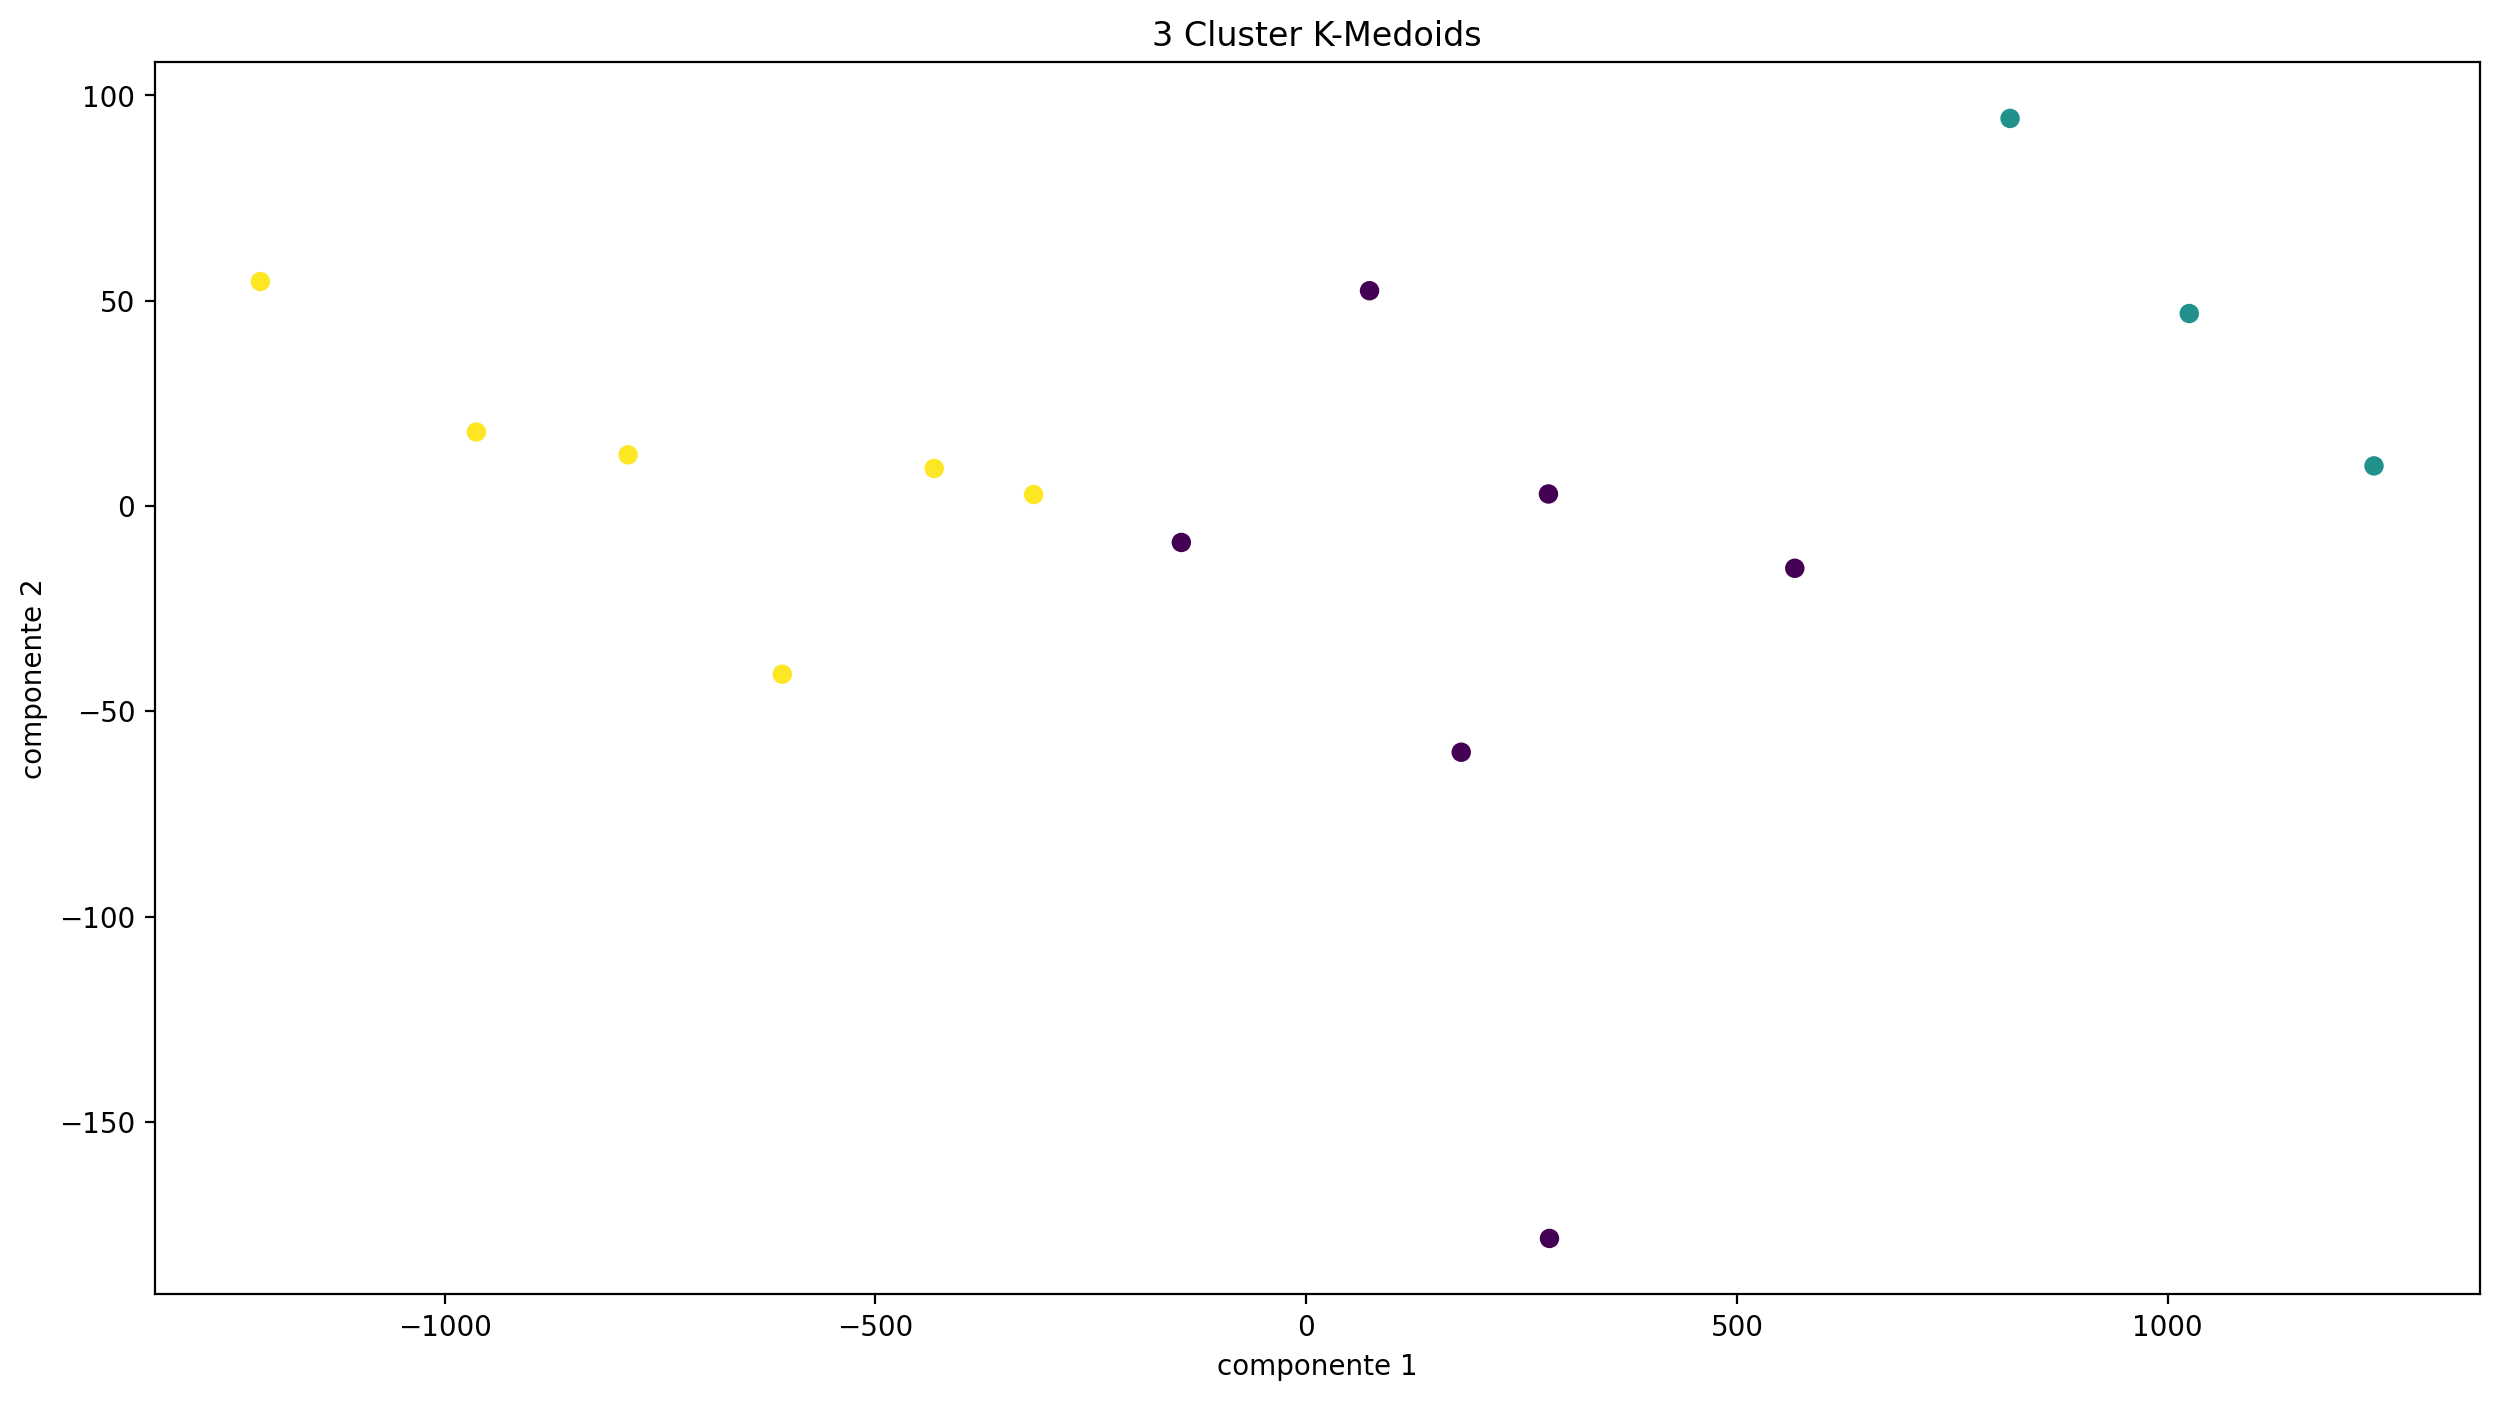

In [17]:
pca = PCA(n_components=2)
componentes = pca.fit_transform(df_numerico)
print("Datos shape\n",df_numerico.shape)
print("Componentes shape\n",componentes.shape)
print("Componentes\n",componentes)

fig, ax = plt.subplots(1,1, figsize = (15,8), dpi = 200)
ax.scatter(componentes[:, 0], componentes[:, 1],c=kmedoids.labels_)
ax.set_xlabel('componente 1')
ax.set_ylabel('componente 2')
ax.set_title('3 Cluster K-Medoids')
plt.show()

In [19]:
#opción f Codo de Jambu

# Cálculo de variazas intra-clase 
#Cálculo de varianzas intra-clase según cantidad de clusters
Nc = range(2, 30)
kmediasList = [KMeans(n_clusters=i) for i in Nc]
varianza = [kmediasList[i].fit(df_numerico).inertia_ for i in range(len(kmediasList))]

#Gráfico
fig, ax = plt.subplots(1,1, figsize = (15,8), dpi = 200)
ax.plot(Nc,varianza,'o-')
ax.set_xlabel('Número de clústeres')
ax.set_ylabel('Varianza explicada por cada cluster (Inercia Intraclases)')
ax.set_title('Codo de Jambu')
plt.show()
# Se estabiliza entre el  K=11 - K=13 aproximadamente

ValueError: n_samples=15 should be >= n_clusters=16.